In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
from sklearn.decomposition import PCA
warnings.filterwarnings("ignore")

#### Same logic as previous notebook but mixing the sample code provided by the course staff with my own code. The main difference is the structure of the data and the logic of the group where I previously grouped by user only, now it is by user label and by radar. I am now also aligning the radar data lengths before stacking.

In [70]:
dataset_path = os.path.realpath(
    os.path.join(
        os.getcwd(),
        "..",
        "Radar",
        "C3"
    )
)

In [71]:
emotions = {
    "E01": "focus",
    "E02": "distraction",
    "E03": "stress",
    "E04": "relaxation",
    "E05": "depression",
    "E06": "excitement"
}

#### Feature extraction helpers

In [72]:
def compute_trajectory_features(xyz, speed):
    trajectory_length = np.sum(speed)

    displacement = np.linalg.norm(xyz[-1] - xyz[0])

    path_efficiency = (
        displacement / trajectory_length
        if trajectory_length > 1e-6 else 0
    )

    mins = np.min(xyz, axis=0)
    maxs = np.max(xyz, axis=0)

    bounding_box_volume = np.prod(maxs - mins)

    return trajectory_length, displacement, path_efficiency, bounding_box_volume

In [73]:
def compute_motion_features(xyz):
    if len(xyz) >= 3:

        pca = PCA(n_components=3)
        pca.fit(xyz)

        movement_anisotropy = pca.explained_variance_ratio_[0]

    else:
        movement_anisotropy = 0

    return movement_anisotropy

In [74]:
def compute_turning_features(velocity_vectors):

    if len(velocity_vectors) >= 2:

        v1 = velocity_vectors[:-1]
        v2 = velocity_vectors[1:]

        norms1 = np.linalg.norm(v1, axis=1)
        norms2 = np.linalg.norm(v2, axis=1)

        valid = (norms1 > 1e-6) & (norms2 > 1e-6)

        if np.sum(valid) > 0:

            v1 = v1[valid]
            v2 = v2[valid]

            norms1 = norms1[valid]
            norms2 = norms2[valid]

            cos_angles = np.sum(v1 * v2, axis=1)

            cos_angles /= (norms1 * norms2)

            cos_angles = np.clip(cos_angles, -1, 1)

            angles = np.arccos(cos_angles)

            mean_turning_angle = np.mean(angles)

        else:
            mean_turning_angle = 0

    else:
        mean_turning_angle = 0

    return mean_turning_angle

In [75]:
def compute_motion_features(speed, acc, jerk):

    max_speed = np.max(speed)
    max_acc = np.max(np.abs(acc))
    max_jerk = np.max(np.abs(jerk))

    return max_speed, max_acc, max_jerk

In [76]:
def compute_motion_bursts(speed):

    threshold = np.mean(speed) + np.std(speed)

    active = speed > threshold

    motion_bursts = np.sum(
        np.diff(active.astype(int)) == 1
    )

    return motion_bursts

In [77]:
def compute_spectral_features(speed):
    spectrum = np.abs(np.fft.rfft(speed))

    freqs = np.fft.rfftfreq(len(speed))

    if len(spectrum) > 1:

        dominant_frequency = freqs[
            np.argmax(spectrum[1:]) + 1
        ]

        spectral_centroid = (
            np.sum(freqs * spectrum)
            / (np.sum(spectrum) + 1e-12)
        )

        psd = spectrum**2
        psd /= np.sum(psd) + 1e-12

        spectral_entropy = -np.sum(
            psd * np.log(psd + 1e-12)
        )

    else:

        dominant_frequency = 0
        spectral_centroid = 0
        spectral_entropy = 0

    return dominant_frequency, spectral_centroid, spectral_entropy

In [78]:
feature_names = [
    "trajectory_length",
    "displacement",
    "path_efficiency",
    "bounding_box_volume",
    "mean_turning_angle",

    "max_speed",
    "max_acc",
    "max_jerk",

    "motion_bursts",

    "dominant_frequency",
    "spectral_centroid",
    "spectral_entropy"
]

def extract_features(xyz, include_list=feature_names):
    velocity_vectors = np.diff(xyz, axis=0)
    speed = np.linalg.norm(velocity_vectors, axis=1)

    acc = np.diff(speed)
    jerk = np.diff(acc)

    if len(speed) == 0:
        speed = np.array([0])

    if len(acc) == 0:
        acc = np.array([0])

    if len(jerk) == 0:
        jerk = np.array([0])

    trajectory_length, displacement, path_efficiency, bounding_box_volume = compute_trajectory_features(xyz, speed)
    mean_turning_angle = compute_turning_features(velocity_vectors)
    max_speed, max_acc, max_jerk = compute_motion_features(speed, acc, jerk)
    motion_bursts = compute_motion_bursts(speed)
    dominant_frequency, spectral_centroid, spectral_entropy = compute_spectral_features(speed)

    features = np.array([])

    if "trajectory_length" in include_list:
        features = np.append(features, trajectory_length)
    if "displacement" in include_list:
        features = np.append(features, displacement)
    if "path_efficiency" in include_list:
        features = np.append(features, path_efficiency)
    if "bounding_box_volume" in include_list:
        features = np.append(features, bounding_box_volume)
    if "mean_turning_angle" in include_list:
        features = np.append(features, mean_turning_angle)
    if "max_speed" in include_list:
        features = np.append(features, max_speed)
    if "max_acc" in include_list:
        features = np.append(features, max_acc)
    if "max_jerk" in include_list:
        features = np.append(features, max_jerk)
    if "motion_bursts" in include_list:
        features = np.append(features, motion_bursts)
    if "dominant_frequency" in include_list:
        features = np.append(features, dominant_frequency)
    if "spectral_centroid" in include_list:
        features = np.append(features, spectral_centroid)
    if "spectral_entropy" in include_list:
        features = np.append(features, spectral_entropy)
        

    return features

In [79]:
from typing import List, Tuple, Union, Optional

NUM_RADARS = 13

def _align_radar_lengths(radar_data_list: List[np.ndarray]) -> List[np.ndarray]:
    lengths = [d.shape[0] for d in radar_data_list]
    min_len = min(lengths)
    return [d[:min_len] for d in radar_data_list]

def preprocess(
    data_dir: str,
    events: list[str]
) -> Union[Tuple[List[np.ndarray], np.ndarray, np.ndarray], Tuple[None, None, None]]:
    if not os.path.exists(data_dir):
        print(f"{data_dir} is not a valid directory")
        return None, None, None

    raw_data = []
    allowed_events = set(events)

    for u in os.listdir(data_dir):
        if not u.startswith("U"):
            continue

        for e in os.listdir(os.path.join(data_dir, u)):
            if not e.startswith("E"):
                continue

            if e not in allowed_events:
                continue
            
            emotion_label = emotions[e]

            radar_folder = os.listdir(os.path.join(data_dir, u, e))
            trial_idx = None
            
            for f in radar_folder:

                dir_path = os.path.join(dataset_path, u, e, f)

                if os.path.isdir(dir_path):

                    radar_files = os.listdir(dir_path)

                    trial_idx = f
                    break

            dir_path = os.path.join(data_dir, u, e, trial_idx)
            

            for f in radar_files:
                file_path = os.path.join(data_dir, u, e, trial_idx, f)
                data = pd.read_pickle(file_path)
                radar_used = "CEILING" if int(f[0]) < 5 else "GROUND"
                sequence = np.vstack(data)

                fs = []
                for s in sequence:

                    xyz = [s[1], s[2], s[3]]
                    if radar_used == "CEILING":
                        xyz = [s[3], s[2], -s[1]]

                    new_s = xyz
                    fs.append(new_s)

                fs = np.array(fs)
                raw_data.append(
                    {
                        "data": fs,
                        "user": u,
                        "label": emotion_label,
                        "trial": trial_idx,
                        "radar": f[0],
                    }
                )
    
    data_list: list[np.ndarray] = []
    labels_list: list[str] = []
    users_list: list[str] = []

    grouped: dict[tuple[str, str, int], list[dict]] = {}
    for item in raw_data:
        key = (item["user"], item["label"], item["trial"])
        grouped.setdefault(key, []).append(item)

    for (u, l, _), group in grouped.items():
        group = sorted(group, key=lambda x: x["radar"])
        radar_data_list = [g["data"] for g in group]
        if len(radar_data_list) != NUM_RADARS:
            continue
        aligned_radars = _align_radar_lengths(radar_data_list)

        sample = np.stack(aligned_radars, axis=0).astype(np.float32)
        data_list.append(sample)
        labels_list.append(l)
        users_list.append(u)

    labels = np.asarray(labels_list)
    users = np.asarray(users_list)

    print(f"final count: data {len(data_list)}, labels {labels.shape}, users {users.shape}")
    return data_list, labels, users

In [80]:
preprocessed_data, labels, users = preprocess(dataset_path, list(emotions.keys()))

final count: data 156, labels (156,), users (156,)


#### Exploring using a window of 15 frames to extract features from instead of the entire frame.

In [81]:
WINDOW_SIZE = 15
STRIDE = 5

In [82]:
def build_windows(
    data: Union[np.ndarray, List[np.ndarray]],
    labels: np.ndarray,
    users: np.ndarray,
) -> Optional[str]:
    samples = list(data) if not (isinstance(data, np.ndarray) and data.dtype != object) else [data[i] for i in range(data.shape[0])]

    win_frames = WINDOW_SIZE
    stride = STRIDE

    X_list: list[np.ndarray] = []
    y_list: list[str] = []
    u_list: list[str] = []

    for i, sample in enumerate(samples):
        if sample is None:
            continue
        _, frames, _ = sample.shape

        if win_frames > frames:
            continue

        for start in range(0, frames - win_frames + 1, stride):
            end = start + win_frames
            n_window = sample[:, start:end, :]
            X_list.append(n_window)
            y_list.append(labels[i])
            u_list.append(users[i])

    X = np.stack(X_list).astype(np.float32)

    y = np.asarray(y_list)
    u = np.asarray(u_list)

    return X, y, u

In [83]:
X, y, u = build_windows(preprocessed_data, labels, users)

In [84]:
def build_radar_feature_dataset(X, feature_fn, include_list=feature_names):
    N, R, T, C = X.shape

    X_feat = []

    for i in range(N):
        sample = X[i]

        radar_feats = []
        valid = True

        for r in range(R):
            seq = sample[r]

            if seq is None or seq.shape[0] < 3:
                valid = False
                break

            # seq = (seq - seq.mean(axis=0)) / (seq.std(axis=0) + 1e-6)
            
            feat = feature_fn(seq, include_list)

            if feat is None:
                valid = False
                break

            radar_feats.append(feat)

        if not valid:
            continue

        radar_feats = np.concatenate(radar_feats, axis=0)
        X_feat.append(radar_feats)

    X_feat = np.asarray(X_feat, dtype=np.float32)

    return X_feat

In [85]:
X_feature = build_radar_feature_dataset(X, extract_features)

In [86]:
X_feature.shape

(2798, 156)

In [87]:
X_feature_mean = np.array([extract_features(x.mean(axis=0)) for x in X])

In [88]:
X_feature_mean.shape

(2798, 12)

In [89]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import classification_report

def train_rf_with_feature_selection(X, y, test_size=0.2, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    rf = RandomForestClassifier(
        n_estimators=300,
        random_state=random_state,
        n_jobs=-1,
        max_depth=None
    )

    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)
    print("=== Full model performance ===")
    print(classification_report(y_test, y_pred))

    importances = rf.feature_importances_

    threshold = np.mean(importances)

    selector = SelectFromModel(rf, threshold=threshold, prefit=True)

    return rf, selector, importances

In [90]:
rf, selector, importances = train_rf_with_feature_selection(X_feature, y)

=== Full model performance ===
              precision    recall  f1-score   support

  depression       0.95      0.60      0.73        99
 distraction       0.78      0.89      0.83        92
  excitement       0.82      0.97      0.89       187
       focus       0.77      0.84      0.80        75
  relaxation       1.00      0.17      0.29        30
      stress       0.69      0.74      0.71        77

    accuracy                           0.80       560
   macro avg       0.83      0.70      0.71       560
weighted avg       0.82      0.80      0.78       560



In [91]:
rf_mean, selector_mean, importances_mean = train_rf_with_feature_selection(X_feature_mean, y)

=== Full model performance ===
              precision    recall  f1-score   support

  depression       0.20      0.09      0.13        99
 distraction       0.54      0.45      0.49        92
  excitement       0.52      0.78      0.63       187
       focus       0.46      0.41      0.43        75
  relaxation       0.25      0.03      0.06        30
      stress       0.51      0.58      0.55        77

    accuracy                           0.49       560
   macro avg       0.41      0.39      0.38       560
weighted avg       0.44      0.49      0.45       560



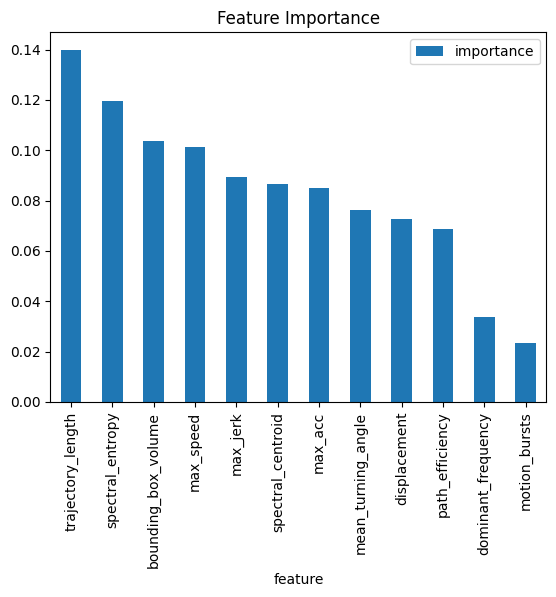

In [92]:
df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances_mean
}).sort_values(by="importance", ascending=False)


df.plot.bar(x="feature", y="importance")
plt.title("Feature Importance")
plt.show()

In [93]:
include_list = df["feature"].tolist()[:7]
include_list

['trajectory_length',
 'spectral_entropy',
 'bounding_box_volume',
 'max_speed',
 'max_jerk',
 'spectral_centroid',
 'max_acc']

In [94]:
X_feature_filtered = build_radar_feature_dataset(X, extract_features, include_list)

In [95]:
X_feature_filtered.shape

(2798, 91)

In [96]:
rf_filtered, selector_filtered, importances_filtered = train_rf_with_feature_selection(X_feature_filtered, y)

=== Full model performance ===
              precision    recall  f1-score   support

  depression       0.96      0.65      0.77        99
 distraction       0.83      0.92      0.88        92
  excitement       0.84      0.97      0.90       187
       focus       0.82      0.87      0.84        75
  relaxation       1.00      0.30      0.46        30
      stress       0.72      0.82      0.77        77

    accuracy                           0.83       560
   macro avg       0.86      0.75      0.77       560
weighted avg       0.85      0.83      0.82       560



In [97]:
np.savez_compressed(
    "radar_features_filtered.npz",
    X=X_feature_filtered.astype(np.float32),
    y=y,
    u=u
)

#### While using this data for models provided good results for random split, it was inneficient for user-wise split. I will try to use the same logic but this time manually pick out the features that I think are relevant and that are not too user-specific to keep the model from overfitting to the users in the training set.

In [98]:
include_list_manual = [
    "spectral_entropy",
    "spectral_centroid",

    "mean_turning_angle",
    "path_efficiency",
    "motion_bursts",
]

In [99]:
X_feature_filtered_manual = build_radar_feature_dataset(
    X, extract_features, include_list_manual
)

In [100]:
np.savez_compressed(
    "radar_features_filtered_manual.npz",
    X=X_feature_filtered_manual.astype(np.float32),
    y=y,
    u=u
)

#### The manually picked features actually perform worse than the filtered set of features.